In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_vGRF_data(label_file_name, record_time_sec):
    output_df = pd.read_csv(label_file_name,
                            delimiter=',',
                            skiprows=4, # skip 4 rows of header
                            nrows=record_time_sec*1000, # read only the specified number of rows
                            encoding_errors='ignore') # Add this line to ignore encoding errors
    output_df = output_df.fillna(0) # fill NaN with 0
    output_buffer = output_df.values
    output_buffer = output_buffer[::10, :] # downsample from 1000Hz to 100Hz

    # 2: R_Fx, 3: R_Fy, 4: R_Fz, 5: R_Mx, 6: R_My, 7: R_Mz, 8: R_CoPx, 9: R_CoPy, 10: R_CoPz,
    # 11: L_Fx, 12: L_Fy, 13: L_Fz, 14: L_Mx, 15: L_My, 16: L_Mz, 17: L_CoPx, 18: L_CoPy, 19: L_CoPz,
    # 20: GPIO
    vGRF_R = - output_buffer[:, 4]  # Right vertical GRF
    vGRF_L = - output_buffer[:, 13] # Left vertical GRF
    return vGRF_R, vGRF_L

def extract_gc(vGRFdata, threshold):
    """
    Extract heel strike indices and form gait cycle segments from GRF data.
    """
    vgrf = vGRFdata.copy()
    # Create binary GRF signal based on threshold
    bi_vgrf = np.where(vgrf < threshold, 0, 1)
    diff_vgrf = np.diff(bi_vgrf)
    # Find indices where the signal goes from 0 to 1
    heelstrike_index = np.where(diff_vgrf == 1)[0] + 1

    # Remove heel strike indices that are too close to each other
    if len(heelstrike_index) > 1:
        diff = np.diff(heelstrike_index)
        # Find indices where the difference is less than 100
        close_idx = np.where(diff < 100)[0]
        # Remove the heel strike indices that are too close to each other
        heelstrike_index = np.delete(heelstrike_index, close_idx+1)

    if len(heelstrike_index) >= 2:
        # Each gait cycle: start at one heel strike and end just before the next
        gait_cycles = np.column_stack((heelstrike_index[:-1], heelstrike_index[1:] - 1))
    else:
        gait_cycles = np.empty((0, 2))
        print("Warning: Not enough gait cycles detected.")

    return heelstrike_index, gait_cycles

def upsampling(data, target_length):
    """
    Upsample a 1D numpy array to the desired target length using linear interpolation.
    """
    original_length = len(data)
    original_indices = np.linspace(0, original_length - 1, original_length)
    new_indices = np.linspace(0, original_length - 1, target_length)

    return np.interp(new_indices, original_indices, data)

def upsampling_2d(data, target_length):
    """
    Upsample a 2D numpy array to the desired target length using linear interpolation.
    data: numpy array of shape (n_features, n_samples)
    target_length: desired length of each segment after upsampling
    """
    upsampled_data = np.zeros((target_length, data.shape[1]))
    for i in range(data.shape[1]):
        upsampled_data[:, i] = upsampling(data[:, i], target_length)

    return upsampled_data  # (target_length, n_features)

def segmenting(data, peak_indices, target_length=100, number_of_cycles=None):
    """
    Segment the data based on gait cycle indices and return all segments and their average.
    data: numpy array of shape (n_samples, n_features)
    peak_indices: numpy array of shape (n_peak) with start and end indices of each gait cycle
    target_length: desired length of each segment after upsampling
    """
    segments = np.zeros((len(peak_indices) - 1, data.shape[1], target_length))

    for n, (start, end) in enumerate(zip(peak_indices[:-1], peak_indices[1:])):
        for i in range(data.shape[1]):
            segment = data[start:end+1, i]
            segment_upsampled = upsampling(segment, target_length)
            segments[n, i, :] = segment_upsampled
    
    if number_of_cycles is not None:
        segments = segments[:number_of_cycles, :, :]

    return segments # (number_of_cycles, n_features, target_length)

def interpolate_two_cycles(cycle1, cycle2, weight):
    interpolated_len = cycle1.shape[0]*weight + cycle2.shape[0]*(1-weight)
    cycle1_upsampled = upsampling_2d(cycle1, int(interpolated_len))
    cycle2_upsampled = upsampling_2d(cycle2, int(interpolated_len))
    interpolated_cycle = cycle1_upsampled * weight + cycle2_upsampled * (1 - weight)
    return interpolated_cycle

def get_average_gait_cycle(df_imu, df_mtr, number_of_cycles=None, side=None):
    # Extract features
    peak_indices, _ = find_peaks(-df_mtr['mtr_pos_L'], height= None, distance=80, prominence=10)
    # print(f"Number of gait cycles: {len(peak_indices) - 1}")

    # Use only the data between the first and last peaks
    average_len = int(np.round((np.mean(np.diff(peak_indices)))))

    data_imu = df_imu.values  # (n_samples, n_features)
    data_mtr = df_mtr.values  # (n_samples, n_features)

    # Segmenting
    segments_imu = segmenting(data_imu, peak_indices, average_len, number_of_cycles)
    segments_mtr = segmenting(data_mtr, peak_indices, average_len, number_of_cycles)

    avg_cycle_imu = np.mean(segments_imu, axis=0)  # (n_features, target_length)
    avg_cycle_mtr = np.mean(segments_mtr, axis=0)  # (n_features, target_length)

    return avg_cycle_imu, avg_cycle_mtr 


In [33]:
root_dir = '/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD_augmented'
speed_conditions = ['0p4mps', '0p6mps', '0p8mps', '1p0mps']

incline_1 = 'LG'
incline_2 = 'RD_5deg'
incline_gen = 'RD_4deg'

# Iterate through all subjects, speeds, and trials
for subject in os.listdir(root_dir):

    dir_1 = os.path.join(root_dir, subject, incline_1)
    dir_2 = os.path.join(root_dir, subject, incline_2)

    for speed in speed_conditions:
        trials_1 = os.listdir(os.path.join(root_dir, subject, incline_1, speed))
        trials_2 = os.listdir(os.path.join(root_dir, subject, incline_2, speed))
        trials = list(set(trials_1) & set(trials_2))  # Use only trials that exist in both conditions

        for trial in trials:
            print(f"Processing Subject: {subject}, Speed: {speed}, Trial: {trial}")
            # Select the first and second dataset for interpolation
            input_imu_1 = os.path.join(dir_1, speed, trial, 'Input', 'imu_data.csv')
            input_df_1 = pd.read_csv(input_imu_1, delimiter=',', on_bad_lines='skip').iloc[:, :].to_numpy()
            label_1 = os.path.join(os.path.join(dir_1, speed, trial, 'Label'), os.listdir(os.path.join(dir_1, speed, trial, 'Label'))[0])

            input_imu_2 = os.path.join(dir_2, speed, trial, 'Input', 'imu_data.csv')
            input_df_2 = pd.read_csv(input_imu_2, delimiter=',', on_bad_lines='skip').iloc[:, :].to_numpy()
            label_2 = os.path.join(os.path.join(dir_2, speed, trial, 'Label'), os.listdir(os.path.join(dir_2, speed, trial, 'Label'))[0])

            vGRF_R_1, vGRF_L_1 = load_vGRF_data(label_1, record_time_sec=29)
            hs_idx_L_1, gc_L_1 = extract_gc(vGRF_L_1, threshold=100)
            hs_idx_R_1, gc_R_1 = extract_gc(vGRF_R_1, threshold=100)

            vGRF_R_2, vGRF_L_2 = load_vGRF_data(label_2, record_time_sec=29)
            hs_idx_L_2, gc_L_2 = extract_gc(vGRF_L_2, threshold=100)
            hs_idx_R_2, gc_R_2 = extract_gc(vGRF_R_2, threshold=100)

            min_gc_cycles = min(len(gc_L_1), len(gc_L_2))
            interpolated_cycles_L, interpolated_cycles_R, interpolated_hs_idx = [], [], []

            for gc in range(min_gc_cycles):
                # print(f"LG Left GC {gc}: {hs_idx_L_1[gc+1]-hs_idx_L_1[gc]} samples, RA5 Left GC {gc}: {hs_idx_L_2[gc+1]-hs_idx_L_2[gc]} samples")
                interpolated_cycle_L = interpolate_two_cycles(
                    cycle1=input_df_1[hs_idx_L_1[gc]:hs_idx_L_1[gc+1], :],
                    cycle2=input_df_2[hs_idx_L_2[gc]:hs_idx_L_2[gc+1], :],
                    weight=0.8
                )
                interpolated_cycles_L.append(interpolated_cycle_L)

            interpolated_hs_idx = np.cumsum([0] + [cycle.shape[0] for cycle in interpolated_cycles_L])

            concatenated_data = np.vstack(interpolated_cycles_L)
            # print(f"Concatenated data shape: {concatenated_data.shape}")

            # Save the interpolated heel strike indices
            npz_save_path = f'{root_dir}/{subject}/{incline_gen}/{speed}/{trial}/Label/interpolated_hs_idx.npz'
            os.makedirs(os.path.dirname(npz_save_path), exist_ok=True)
            np.savez(npz_save_path, interpolated_hs_idx=interpolated_hs_idx)
            
            # Save the concatenated IMU data
            imu_headers = ['time','Pelvis_Acc_X','Pelvis_Acc_Y','Pelvis_Acc_Z','Pelvis_Gyr_X','Pelvis_Gyr_Y','Pelvis_Gyr_Z','Thigh_L_Acc_X','Thigh_L_Acc_Y','Thigh_L_Acc_Z','Thigh_L_Gyr_X','Thigh_L_Gyr_Y','Thigh_L_Gyr_Z','Thigh_R_Acc_X','Thigh_R_Acc_Y','Thigh_R_Acc_Z','Thigh_R_Gyr_X','Thigh_R_Gyr_Y','Thigh_R_Gyr_Z']
            save_path = f'{root_dir}/{subject}/{incline_gen}/{speed}/{trial}/Input/imu_data.csv'
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            pd.DataFrame(concatenated_data, columns=imu_headers).to_csv(
                save_path,
                index=False
            )

Processing Subject: AB07_Leo, Speed: 0p4mps, Trial: trial_2
Processing Subject: AB07_Leo, Speed: 0p4mps, Trial: trial_3
Processing Subject: AB07_Leo, Speed: 0p4mps, Trial: trial_1
Processing Subject: AB07_Leo, Speed: 0p6mps, Trial: trial_2
Processing Subject: AB07_Leo, Speed: 0p6mps, Trial: trial_3
Processing Subject: AB07_Leo, Speed: 0p6mps, Trial: trial_1
Processing Subject: AB07_Leo, Speed: 0p8mps, Trial: trial_2
Processing Subject: AB07_Leo, Speed: 0p8mps, Trial: trial_3
Processing Subject: AB07_Leo, Speed: 0p8mps, Trial: trial_1
Processing Subject: AB07_Leo, Speed: 1p0mps, Trial: trial_2
Processing Subject: AB07_Leo, Speed: 1p0mps, Trial: trial_3
Processing Subject: AB07_Leo, Speed: 1p0mps, Trial: trial_1
Processing Subject: AB05_Maria, Speed: 0p4mps, Trial: trial_2
Processing Subject: AB05_Maria, Speed: 0p4mps, Trial: trial_3
Processing Subject: AB05_Maria, Speed: 0p4mps, Trial: trial_1
Processing Subject: AB05_Maria, Speed: 0p6mps, Trial: trial_2
Processing Subject: AB05_Maria, 

[   0  125  249  375  500  621  742  869  993 1118 1244 1369 1493 1617
 1742 1865 1991 2113 2237 2362 2490 2616]


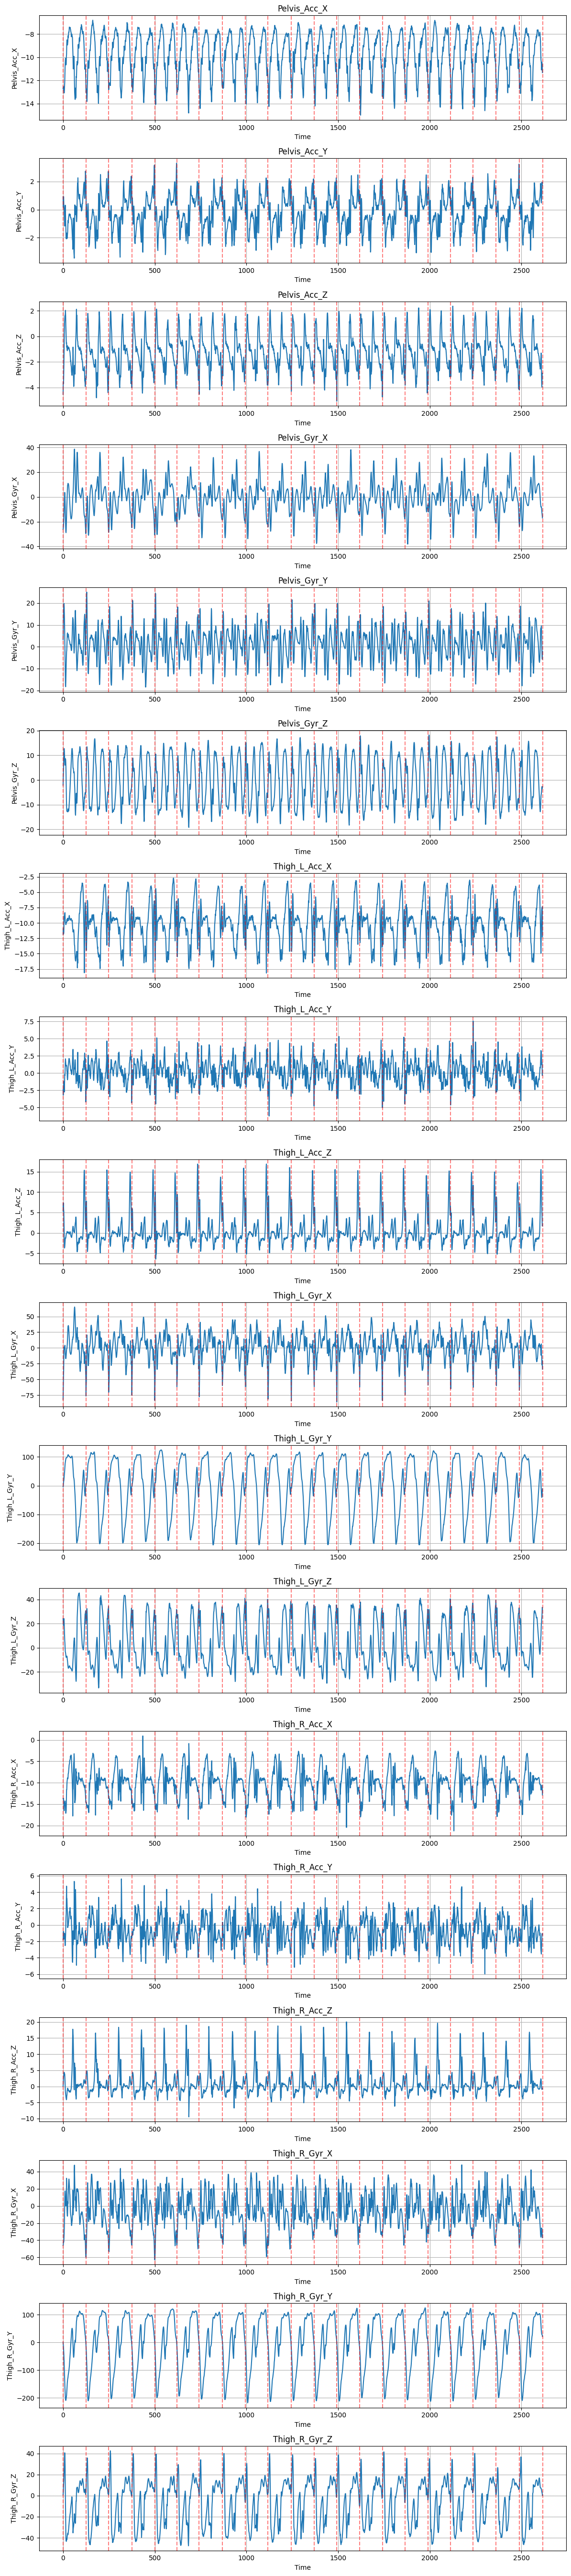

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
csv_path = '/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD_augmented/AB01_Jimin/RA_2p5deg/1p0mps/trial_1/Input/imu_data.csv'
df_plot = pd.read_csv(csv_path)

# Load the npz file with heel strike indices
npz_path = '/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD_augmented/AB01_Jimin/RA_2p5deg/1p0mps/trial_1/Label/interpolated_hs_idx.npz'
npz_data = np.load(npz_path)
interpolated_hs_idx = npz_data['interpolated_hs_idx']
print(interpolated_hs_idx)

# Create subplots for all columns except 'time'
fig, axes = plt.subplots(len(df_plot.columns)-1, 1, figsize=(12, 3*(len(df_plot.columns)-1)))

for i, col in enumerate(df_plot.columns[1:]):  # Skip 'time' column
    axes[i].set_title(col)
    axes[i].plot(df_plot[col])
    for idx in interpolated_hs_idx:
        axes[i].axvline(x=idx, color='r', linestyle='--', alpha=0.5)
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Time')
    axes[i].grid(True)

plt.tight_layout()
plt.show()



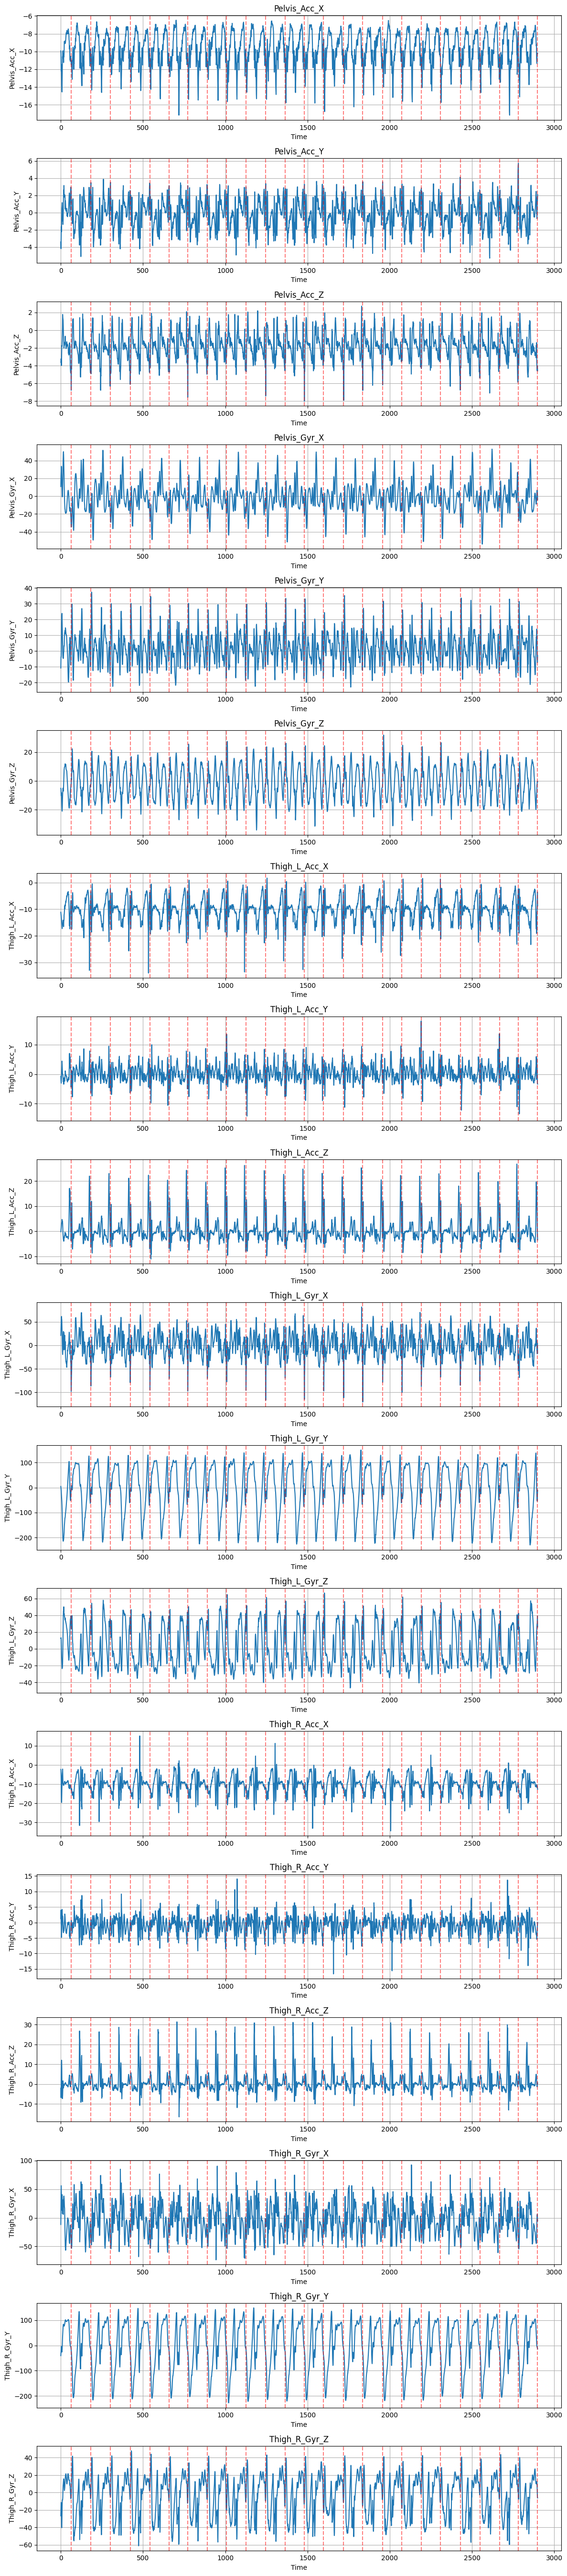

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
csv_path = '/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD_augmented/AB01_Jimin/LG/1p0mps/trial_1/Input/imu_data.csv'
df_plot = pd.read_csv(csv_path)

# Load the npz file with heel strike indices
label_file = '/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD_augmented/AB01_Jimin/LG/1p0mps/trial_1/Label/AB01_Jimin_1p0mps_1.csv'
vGRF_R_1, vGRF_L_1 = load_vGRF_data(label_file, record_time_sec=29)
hs_idx_L_1, gc_L_1 = extract_gc(vGRF_L_1, threshold=100)

# Create subplots for all columns except 'time'
fig, axes = plt.subplots(len(df_plot.columns)-1, 1, figsize=(12, 3*(len(df_plot.columns)-1)))

for i, col in enumerate(df_plot.columns[1:]):  # Skip 'time' column
    axes[i].set_title(col)
    axes[i].plot(df_plot[col])
    for idx in hs_idx_L_1:
        axes[i].axvline(x=idx, color='r', linestyle='--', alpha=0.5)
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Time')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

